<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Pro/AI_HW6_uplift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Задание по Uplift-моделированию </h1>

<h2>Введение</h2>

Перед вами типичная задача, возникающая при работе с моделями кампейнинга в банке: заказчик запустил несколько пилотов по взаимодействию с клиентами с помощью разных каналов: push в мобильном приложении, sms, баннеры в мобильном приложении и реклама в других приложениях экосистемы. Заказчик хотел бы понимать, какой канал взаимодействия с клиентом наиболее эффективен для каждого клиента из клиентской базы. Кампании планируются и запускаются в ежемесячном режиме. Иными словами, заказчик хотел бы в идеале ежемесячно получать список клиентов, которым необходимо отправить коммуникацию с указанием канала и прироста вероятности покупки в случае, если клиенту отправят коммуникацию по сравнению с тем случаем, когда клиенту коммуникацию не отправят.

<b>Таким образом: </b>
1.	У нас есть база клиентов (клиенты, имеющие id в банке). По данной базе осуществляется рассылка тех или иных стимулирующих коммуникаций по различным продуктам, каналам (например SMS, Push, баннеры в мобильном приложении и т.д.) и сегментам клиентов
2.	Признаковое описание клиента состоит из различных агрегатов действий клиента за месяц или его объективных характеристик: например, средняя сумма средств на депозитах за месяц, среднее число кликов клиента в день за месяц в разделе "инвестиции" в мобильном приложении или возраст клиента
3.	При формировании обучающей/тестовой выборки допускается, что один и тот же клиент за разные месяцы — это разные объекты. То есть допускается, что клиент в феврале и клиент в марте — это разные клиенты (то есть мы можем оперировать с ними как с разными сущностями).
4.	Агрегаты действий клиента за месяц появляются примерно 10 числа следующего месяца. То есть, например, агрегаты за декабрь появляются 10 января. В свою очередь списки клиентов, которым необходимо осуществить рассылку должны быть сформированы ориентировочно 20 числа предыдущего месяца. Таким образом, <b> модель должна быть обучена делать предсказания с лагом в два месяца </b>, то есть должна делать предсказание на март по клиентским агрегатам за январь. Обязательно учтите это при обучении модели (в противном случае можно получить лик таргета, так как часто величину, которую мы предсказываем уже есть в клиентских агрегатах, но смещенная на два месяца).


## Оценивание задания:

Всего за задание можно получить 50 первичных баллов, которые затем переводятся в 10-балльную шкалу делением не 5.

Скачаем архив с данными по ссылке и разархивируем.

In [1]:
import sns
!pip install gdown -q

In [2]:
import gdown

url = 'https://disk.yandex.ru/d/g9LzEzOc_O-r1'
output = 'Data.zip'
gdown.download(url, output, quiet=False)

Downloading...
From: https://disk.yandex.ru/d/g9LzEzOc_O-r1
To: D:\PyCharm Projects\hw2-gradient\UPLIFT\Data.zip
43.6kB [00:00, 5.65MB/s]


'Data.zip'

In [3]:
import os
import pandas as pd

campaigns = pd.read_csv("./CAMPAINGS.csv")
print(type(campaigns))
contracts = pd.read_csv("./CONTRACTS_FINAL.csv")
people = pd.read_csv("./PEOPLE_IN_CAMPAINGS_FINAL.csv")
aggs = pd.read_csv("./AGGS_FINAL.csv")


<class 'pandas.DataFrame'>


<h2>Описание данных</h2>

Перед вами несколько наборов данных, на основе которых вам будет необходимо обучить Uplift модели, сделать прогноз на нужный месяц и решить, кому из клиентов отправлять коммуникацию, а кому коммуникацию отправлять не следует.

<h3>Features </h3> Признаки клиентов, клиентские агрегаты, которые описывают поведение клиентов <br>

1. user_id - id клиента
2. report_dt - месяц, на который актуальны признаки
3. city - город, в котором живет клиент
4. age - возраст клиента
5. x1 – x9 - числовые признаки клиента, характеризующие поведение клиента

Первичный ключ таблицы - user_id + report_dt

<h3> Contracts </h3> Таблица с покупками продуктов.

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h3> Campaings </h3> Кампании, которые проводились (под кампанией мы понимаем рассылку sms, push и т.д).

1. campaing_id - id кампании, первичный ключ таблицы
2. product_id - продукт, по которому проводилась кампания (считаем, что продукты не конкурируют друг с другом)
3. channel - канал, в котором проводилась кампания


<h3> People_in_campaings </h3> Люди, которые принимали участие в кампаниях.

1. campaing_id - id кампании
2. user_id - id пользователя, который попал в кампанию
3. флаг целевой (1) и контрольной (0) группы (целевая группа - это те, кто получил коммуникацию, а контрольная - те, кто нет)
4. delivery_ts - timestamp, когда клиенту фактически была доставлена коммуникация (для контрольной группы nan, подумайте почему)

Первичный ключ данной таблицы - user_id + campaing_id


<h3> Contracts </h3> Таблица с покупками продуктов

1. contract_id - id покупки
2. user_id - id пользователя, который совершил покупку
3. product_id - id продукта, который был куплен
4. contract_ts – дата момента, когда была совершена покупка

Первичный ключ - contract_id


<h1> Постановка задачи </h1> В ноябре 2024 проводилось несколько кампаний по продукту с id 0001 (фактически клиенту рассылалось одно и тоже сообщение, но в разных каналах). Вам необходимо по данным кампаниям построить модель, которая будет определять лучший канал коммуникации каждого клиента и определить, кому из клиентов в марте 2025 отправить какую коммуникацию, а кому коммуникацию вообще отправлять не следует.
Ответ нужно представить в следующем виде (report_dt – дата фичей):

<table>
  <thead>
    <tr>
      <th>user_id</th>
      <th>report_dt</th>
      <th>channel</th>
      <th>uplift</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>10045</td>
      <td>2025-01-31</td>
      <td>banner</td>
      <td>0.07</td>
    </tr>
    <tr>
      <td>10046</td>
      <td>2025-01-31</td>
      <td>no_comm</td>
      <td>0.00</td>
    </tr>
    <tr>
      <td>10047</td>
      <td>2025-01-31</td>
      <td>sms</td>
      <td>0.23</td>
    </tr>
    <tr>
      <td>10048</td>
      <td>2025-01-31</td>
      <td>push</td>
      <td>0.19</td>
    </tr>
  </tbody>
</table>

<h1> Декомпозиция задачи </h1>

<h2> 1.	Сбор и анализ таргета (18 баллов)</h2>

Прежде всего, вам необходимо собрать целевое событие, которое вы собираетесь прогнозировать. В данном случае целевое событие - это покупка продукта 0001 пользователем, участвовавшем в кампании. Обратите внимание, что не все пользователи получают коммуникацию одновременно (delivery_ts в таблице People_in_campaings). Согласно правилу, согласованному с заказчиком, <b> человек из целевой группы купил продукт после коммуникации - это значит, что он купил его в течение 2х недель после получения сообщения, а человек из контрольной - в течение 3х недель с момента старта кампании (старт кампании - начало месяца). </b> То есть для определенной кампании, для каждого клиента, попавшего в кампанию, вам надо будет найти его покупки данного продукта, а потом основываяся на данном правиле превратить покупки в 0 или 1. <br> На выходе у вас должен появиться таблица с целевым действием для каждого канала (колонки client_id, report_dt,  target), где таргет - это бинарная переменная (0 или 1). Колонка report_dt вам нужна как техническая колонка для дальнейших джоинов.<br><br>

Проведите анализ полученных данных (до присоединения клиентских агрегатов). Какие проблемы и сложности в данных вы обнаружили? Что с ними можно сделать? Какая из кампаний наиболее эффективная? Подготовьте выводы по полученным инсайтам.


**Комментарий по заданиям и оцениванию:**

* Вы должны самостоятельно сделать join нескольких таблиц, самостоятельно собрать целевое действие

* Представлены 4 различных канала, за таргет по каждому из каналов можно получить **максимум 2 балла**:
    * 1 балл за то, что просчитано целевое действие для целевой группы (покупка в
течение одной-двух недель с момента получения коммуникации)
    * 1 балл за то, что просчитано целевое действие для контрольной группы (покупка в течение двух-трех недель с момента старта кампании) и сделана таблица в требуемом формате

* Обратите внимание, что не во всех кампаниях содержатся корректные данные для проведения моделирования, и вам необходимо провести анализ данных и в случае выявленных некорректностей - описать их, и не проводить моделирование для "сломанной" кампании  
    * За данный анализ можно получить **8 баллов**

* Вы должны оценить эффективность кампаний по uplift (cреднее значение таргета в целевой минус среднее значение таргета в контрольной группе)
    * За данный анализ можно получить **2 балла**

In [4]:
print(len(people))

520000


In [5]:
people_push = people[people['campaing_id'] == 'iddqd']
print(len(people_push))

people_push_unknown = people_push[people_push['delivery_date']=='unknown']
print(len(people_push_unknown))

people_push_date = people_push[people_push['delivery_date']!='unknown']
print(len(people_push_date))

unknown_users = set(people_push_unknown['user_id'])
date_users = set(people_push_date['user_id'])

intersection_users = unknown_users & date_users 
print(f"Количество пересекающихся пользователей: {len(intersection_users)}")

160000
80000
80000
Количество пересекающихся пользователей: 0


In [6]:
people_sms = people[people['campaing_id'] == 'idclip']
print(len(people_sms))

people_sms_unknown = people_sms[people_sms['delivery_date']=='unknown']
print(len(people_sms_unknown))

people_sms_date = people_sms[people_sms['delivery_date']!='unknown']
print(len(people_sms_date))

unknown_users = set(people_sms_unknown['user_id'])
date_users = set(people_sms_date['user_id'])

intersection_users = unknown_users & date_users 
print(f"Количество пересекающихся пользователей: {len(intersection_users)}")

120000
60000
60000
Количество пересекающихся пользователей: 0


In [7]:
people_banner = people[people['campaing_id'] == 'iddt']
print(len(people_banner))

people_banner_unknown = people_banner[people_banner['delivery_date']=='unknown']
print(len(people_banner_unknown))

people_banner_date = people_banner[people_banner['delivery_date']!='unknown']
print(len(people_banner_date))

unknown_users = set(people_banner_unknown['user_id'])
date_users = set(people_banner_date['user_id'])

intersection_users = unknown_users & date_users 
print(f"Количество пересекающихся пользователей: {len(intersection_users)}")

120000
60000
60000
Количество пересекающихся пользователей: 0


In [8]:
people_other_ads = people[people['campaing_id'] == 'idkfa']
print(len(people_other_ads))

people_other_ads_unknown = people_other_ads[people_other_ads['delivery_date']=='unknown']
print(len(people_other_ads_unknown))

people_other_ads_date = people_other_ads[people_other_ads['delivery_date']!='unknown']
print(len(people_other_ads_date))

unknown_users = set(people_other_ads_unknown['user_id'])
date_users = set(people_other_ads_date['user_id'])

intersection_users = unknown_users & date_users 
print(f"Количество пересекающихся пользователей: {len(intersection_users)}")

120000
60000
60000
Количество пересекающихся пользователей: 0


In [9]:
# Получаем множества user_id для каждой кампании
push_users = set(people_push['user_id'])
sms_users = set(people_sms['user_id'])
banner_users = set(people_banner['user_id'])
other_ads_users = set(people_other_ads['user_id'])

campaignsDict = {
    'push': push_users,
    'sms': sms_users,
    'banner': banner_users,
    'other_ads': other_ads_users
}


campaign_names = list(campaignsDict.keys())
for i in range(len(campaign_names)):
    for j in range(i + 1, len(campaign_names)):
        campaign1 = campaign_names[i]
        campaign2 = campaign_names[j]
        intersection = campaignsDict[campaign1] & campaignsDict[campaign2]
        print(f"{campaign1} и {campaign2}: {len(intersection)} пользователей")



push и sms: 60000 пользователей
push и banner: 0 пользователей
push и other_ads: 0 пользователей
sms и banner: 0 пользователей
sms и other_ads: 0 пользователей
banner и other_ads: 0 пользователей


Проблема была в том что целевые группы по смс и пушу пересекались.
Кампания по СМС была неправильно передана в данных - ее для дальнейшего мы использовать не будем.
Это и есть та сломанная кампания.


In [10]:
push_users = set(people_push['user_id'])
sms_users = set(people_sms['user_id'])
overlap_users = push_users & sms_users

pure_push = people_push[~people_push['user_id'].isin(overlap_users)]
pure_sms = people_sms[~people_sms['user_id'].isin(overlap_users)]

print(f"Только push: {len(pure_push)}")
print(f"Только смс: {len(pure_sms)}")

Только push: 100000
Только смс: 60000


In [11]:
#PUSH
people_push_unknown = people_push[people_push['delivery_date'] == 'unknown']
print(f"PUSH, unknown дата: {len(people_push_unknown)}")

people_push_date = people_push[people_push['delivery_date'] != 'unknown']
print(f"PUSH, дата коммуникации: {len(people_push_date)}")

#SMS
people_sms_unknown = pure_sms[pure_sms['delivery_date'] == 'unknown']
print(f"SMS, unknown дата: {len(people_sms_unknown)}")

people_sms_date = pure_sms[pure_sms['delivery_date'] != 'unknown']
print(f"SMS, дата коммуникации: {len(people_sms_date)}")

PUSH, unknown дата: 80000
PUSH, дата коммуникации: 80000
SMS, unknown дата: 0
SMS, дата коммуникации: 60000


In [12]:
from datetime import timedelta

people = pd.concat([
    people_push,
    people_banner,
    people_other_ads
], ignore_index=True)

print(len(people))

upliftDf = (people
          .merge(contracts, on='user_id', how='left'))

print(upliftDf.head(5))

uplift = upliftDf
uplift['delivery_date_dt'] = pd.to_datetime(uplift['delivery_date'], errors='coerce')
uplift['contract_date_dt'] = pd.to_datetime(uplift['contract_date'], errors='coerce')

uplift['campaign_start'] = uplift['contract_date_dt'].dt.to_period('M').dt.start_time

uplift['uplift_target'] = uplift.apply(
    lambda row: (
        1 if (row['t_flag'] == 1
             and pd.notna(row['delivery_date_dt'])
             and pd.notna(row['contract_date_dt'])
             and (row['contract_date_dt'] - row['delivery_date_dt']) <= timedelta(days=14))
        else 1 if (row['t_flag'] == 0
             and pd.notna(row['contract_date_dt'])
             and pd.notna(row['campaign_start'])
             and (row['contract_date_dt'] - row['campaign_start']) <= timedelta(weeks=3))
        else 0
    ), axis=1
)

400000
   Unnamed: 0_x campaing_id  user_id  t_flag delivery_date  Unnamed: 0_y  \
0         36627       iddqd     1162       1    2024-11-08      132706.0   
1        134015       iddqd    42991       1    2024-11-07           NaN   
2         48671       iddqd    24623       0       unknown           NaN   
3        138683       iddqd   116064       0       unknown       51111.0   
4        159093       iddqd   139714       0       unknown           NaN   

  contract_date  product_id             contract_id  
0    2024-11-13         1.0    0001_2024-11-13_1162  
1           NaN         NaN                     NaN  
2           NaN         NaN                     NaN  
3    2024-11-08         1.0  0001_2024-11-08_116064  
4           NaN         NaN                     NaN  


In [13]:
campaign_mapping = campaigns.set_index('campaing_id')['channel'].to_dict()
uplift['channel'] = uplift['campaing_id'].map(campaign_mapping)

uplift_full = pd.DataFrame({
    'userId': uplift['user_id'],
    'report_dt': None,  
    't_flag': uplift['t_flag'],
    'campaing_id': uplift['campaing_id'],
    'delivery': uplift['delivery_date_dt'],
    'channel': uplift['channel'],  
    'target': uplift['uplift_target']
})

print(uplift_full.head(50))


    userId report_dt  t_flag campaing_id   delivery channel  target
0     1162      None       1       iddqd 2024-11-08    push       1
1    42991      None       1       iddqd 2024-11-07    push       0
2    24623      None       0       iddqd        NaT    push       0
3   116064      None       0       iddqd        NaT    push       1
4   139714      None       0       iddqd        NaT    push       0
5   127278      None       0       iddqd        NaT    push       0
6   113131      None       0       iddqd        NaT    push       0
7      709      None       1       iddqd 2024-11-07    push       1
8    66294      None       0       iddqd        NaT    push       0
9     3365      None       0       iddqd        NaT    push       0
10   35254      None       0       iddqd        NaT    push       0
11   17423      None       0       iddqd        NaT    push       0
12  137984      None       0       iddqd        NaT    push       1
13   58389      None       0       iddqd        

In [14]:
uplift_full['report_dt'] = pd.to_datetime('2024-11-30')
uplift_full.rename(columns={'userId': 'client_id'}, inplace=True)
final_columns = ['client_id', 'report_dt', 'target']
uplift_final = uplift_full[final_columns].copy()

print("Итоговая таблица (первые 5 строк):")
print(uplift_final.head())

test = uplift_full[uplift_full['t_flag'] == 1]
control = uplift_full[uplift_full['t_flag'] == 0]


test_stats = test.groupby('campaing_id').agg(
    test_target_mean=('target', 'mean')
).reset_index()

control_stats = control.groupby('campaing_id').agg(
    control_target_mean=('target', 'mean'),
).reset_index()

uplift_by_campaign = pd.merge(test_stats, control_stats, on='campaing_id', how='inner')

uplift_by_campaign['uplift'] = uplift_by_campaign['test_target_mean'] - uplift_by_campaign['control_target_mean']

uplift_by_campaign = uplift_by_campaign.sort_values('uplift', ascending=False)

print("\nUplift по кампаниям:")
print(uplift_by_campaign)


Итоговая таблица (первые 5 строк):
   client_id  report_dt  target
0       1162 2024-11-30       1
1      42991 2024-11-30       0
2      24623 2024-11-30       0
3     116064 2024-11-30       1
4     139714 2024-11-30       0

Uplift по кампаниям:
  campaing_id  test_target_mean  control_target_mean    uplift
0       iddqd          0.687025             0.202150  0.484875
2       idkfa          0.702267             0.400733  0.301533
1        iddt          0.687750             0.400733  0.287017


### ваши выводы здесь

<h2> 2. Клиентские агрегаты (12 баллов)</h2>

Присоедините клиентские агрегаты (будьте внимательны, присоедините агрегаты за корректный месяц) и изучите полученные данные.

**Комментарий по заданиям и оцениванию:**

* Вы должны корректно присоединить клиентские агрегаты со смещением на два месяца, чтобы не было лика таргета. За данное действие можно получить **4 балла**

* Далее вы должен сделать UPLIFT EDA, которые обсуждались на лекции и показывались в практических ноутбуках. В ходе анализа вы должны проверить корректность данных по рекламным кампаниям и решить, что делать со "сломанными" кампаниями. По итогам анализа подготовьте выводы. За данное действие можно получить **8 баллов**

In [15]:
# ваш код здесь
uplift_final['delivery_date_dt'] = pd.to_datetime(uplift_full['delivery'], errors='coerce')
aggs['report_dt'] = pd.to_datetime(aggs['report_dt'])
aggs['year'] = aggs['report_dt'].dt.year
aggs['month'] = aggs['report_dt'].dt.month

aggs_sep = aggs[(aggs['year'] == 2024) & (aggs['month'] == 9)].copy()

aggs_sep = aggs_sep.drop_duplicates(subset=['user_id'])

uplift_aggs = uplift_full.merge(
    aggs_sep[['user_id', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'age', 'city']],
    left_on='client_id',
    right_on='user_id',
    how='left'
)

required_columns = ['user_id', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 
                    'age', 'city', 't_flag', 'channel', 'target']

uplift_final = uplift_aggs[required_columns]

print(len(uplift_final))
print(uplift_final.head(15))

400000
    user_id        x1        x2        x3        x4        x5        x6  \
0      1162 -1.224545  1.688111  0.150933  3.230149 -0.189105  0.551481   
1     42991 -0.916137  1.368764  1.841319 -1.529691 -0.608003 -1.116932   
2     24623  2.281651 -0.354332  1.288191 -2.754188  0.202581  0.831745   
3    116064 -0.773911  1.877601  0.582218  1.699295 -0.667554 -0.018505   
4    139714  0.457746  1.407223  0.803963 -2.002316  0.928291 -1.389908   
5    127278 -1.036319  4.486592  0.300893 -0.292962  1.722243  0.912058   
6    113131 -0.241780  0.694004  3.727442  0.123355  0.730687 -0.445661   
7       709  1.093347  0.616609  0.454148 -2.075121  0.315698  0.284558   
8     66294  1.917110  0.547769 -1.187122  0.360652 -0.070706 -1.828424   
9      3365  0.538273 -0.061897  2.200289 -0.415102  0.867456 -0.747729   
10    35254  0.094235  2.411096  2.048148 -1.103246  2.211573  1.456595   
11    17423  0.318847  0.869118  1.651635  0.284416  0.751942 -0.058673   
12   137984 -1.335

In [16]:
uplift_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   user_id  400000 non-null  int64  
 1   x1       400000 non-null  float64
 2   x2       400000 non-null  float64
 3   x3       400000 non-null  float64
 4   x4       400000 non-null  float64
 5   x5       400000 non-null  float64
 6   x6       400000 non-null  float64
 7   x7       400000 non-null  float64
 8   x8       400000 non-null  float64
 9   x9       400000 non-null  float64
 10  age      400000 non-null  int64  
 11  city     400000 non-null  str    
 12  t_flag   400000 non-null  int64  
 13  channel  400000 non-null  str    
 14  target   400000 non-null  int64  
dtypes: float64(9), int64(4), str(2)
memory usage: 45.8 MB


In [17]:
x_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 't_flag']

x_cols_with_flag = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 't_flag']

uplift_final_x = uplift_final[x_cols_with_flag]

uplift_final_x.groupby(by='t_flag').mean()

,x1,x2,x3,x4,x5,x6,x7,x8,x9
t_flag,,,,,,,,,
0,0.121318,-0.206758,0.513065,-0.363408,0.238925,-0.001426,0.200459,0.200184,0.070822
1,0.126389,-0.195641,0.519762,-0.358292,0.238669,0.000452,0.199731,0.198180,0.068936


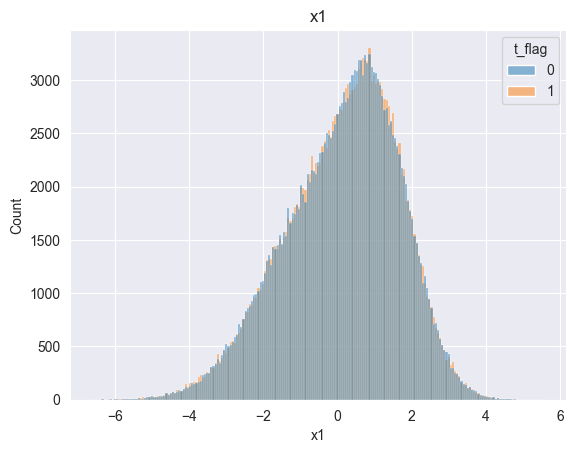

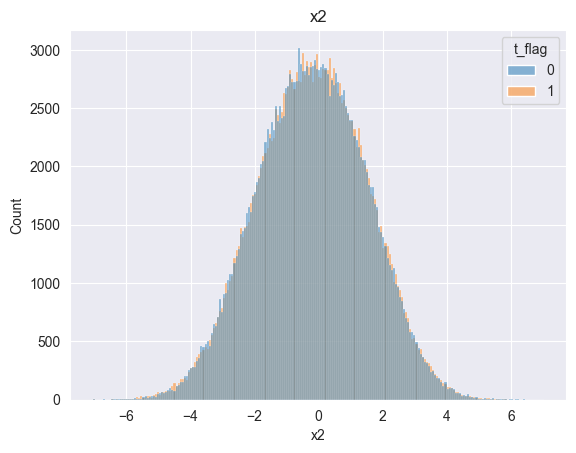

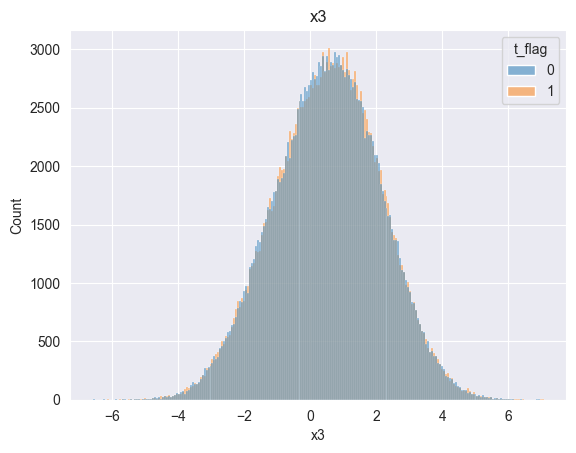

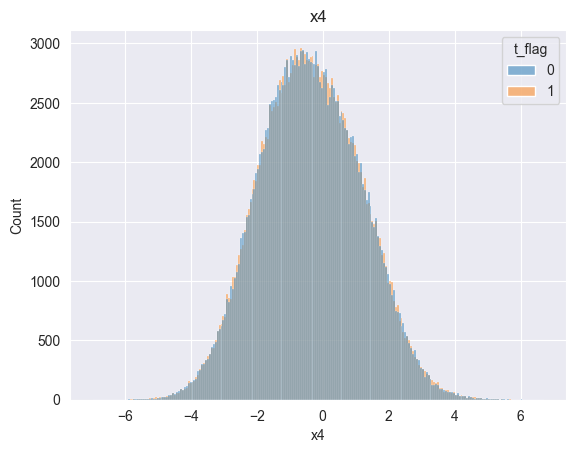

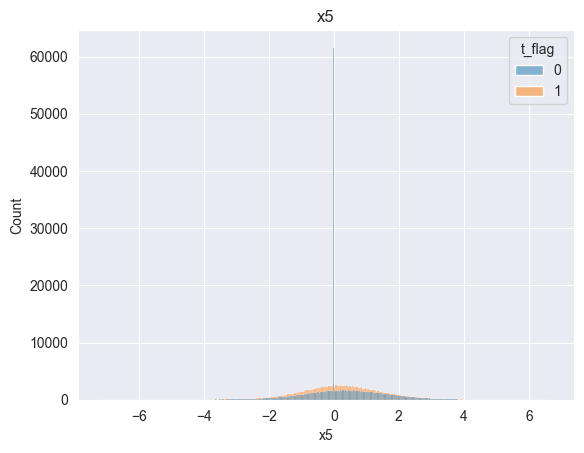

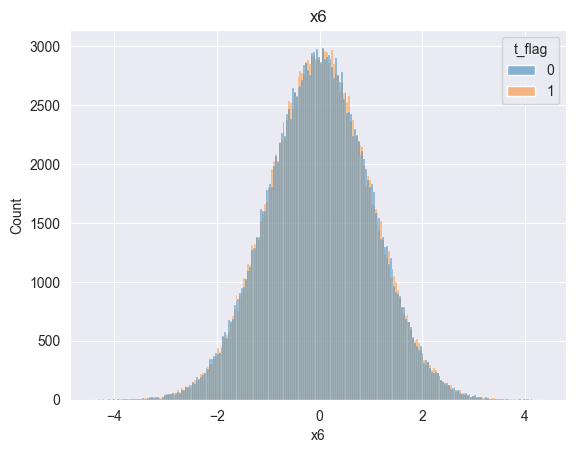

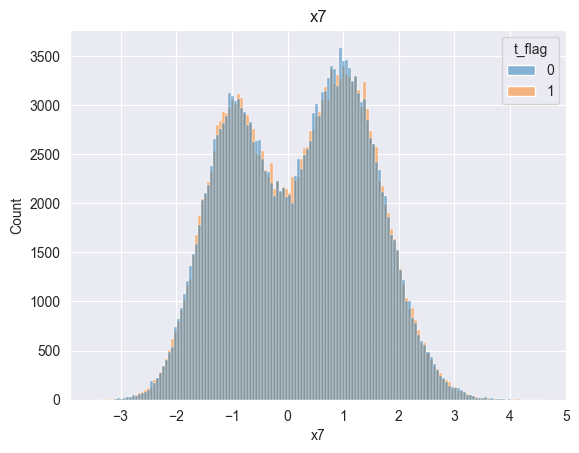

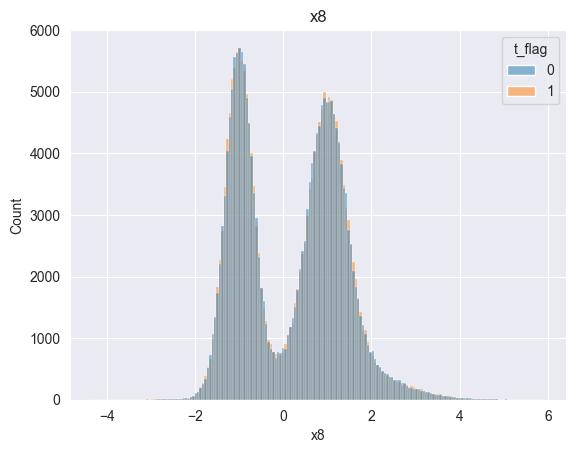

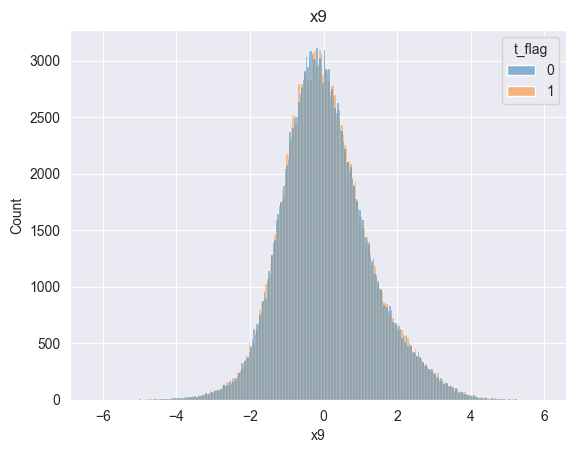

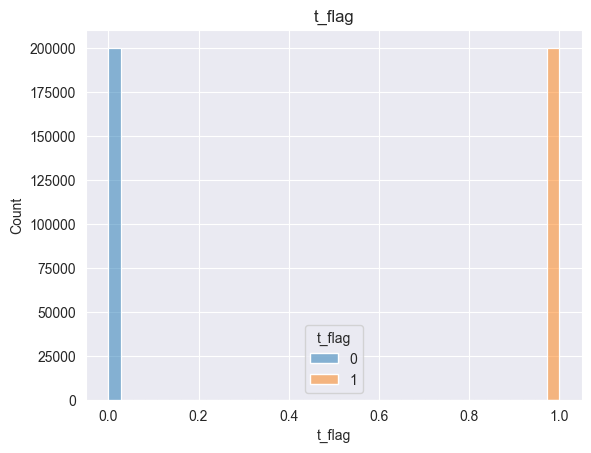

In [18]:
from matplotlib import pyplot as plt
import seaborn as sns

for col in x_cols:
    sns.histplot(data = uplift_final, x=col, hue='t_flag').set_title(col)
    plt.show()

### ваши выводы здесь

<h2> 3. Построение моделей и оценка их качества (14 баллов)</h2>

Постройте Uplift модели по собранным кампаниям, проведите тюнинг гиперпараметров и оцените их качество (qini score). Для каждой модели также постройте qini-curve.

**Комментарий по заданиям и оцениванию:**

* Реализован только подход Solomodel без дополнительных библиотек и калибровок  - **1 балл**

* Реализован Solomodel или Twomodel через Sklift или CausalML - **2 балла**

* Учтена калибровка Metalearner'ах - **2 балла**

* Корректно реализован ClassTransformation - **2 балла**

* Реализован UpliftRandomForest - **4 балла**

* Использованы пайплайны в Sklift - **2 балла**

* Реализован тюнинг ( Gridsearch \ Optuna ) - **1 балл**

In [19]:
!pip install scikit-uplift

In [27]:
# ваш код здесь

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split,
                                     cross_validate,
                                     StratifiedKFold)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

from causalml.dataset import make_uplift_classification
from causalml.inference.tree import UpliftRandomForestClassifier

import optuna

from catboost import CatBoostClassifier

from sklift.models import (SoloModel,
                           TwoModels,
                           ClassTransformation,
                           ClassTransformationReg)
from sklift.metrics import (uplift_at_k,
                            uplift_auc_score,
                            qini_auc_score,
                            make_uplift_scorer)
from sklift.viz import plot_qini_curve, plot_uplift_curve

ImportError: cannot import name 'check_matplotlib_support' from 'sklearn.utils' (C:\Users\Альберт\PycharmProjects\hse-dev-tools-khakimovae\venv\Lib\site-packages\sklearn\utils\__init__.py)

In [28]:
 !pip install --upgrade scikit-uplift

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklift.metrics import uplift_at_k, uplift_auc_score, uplift_curve

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

city_encoded = encoder.fit_transform(uplift_final[['city']])
city_df = pd.DataFrame(
    city_encoded,
    columns=encoder.get_feature_names_out(['city']),
    index=uplift_final.index
)

uplift_encoded = pd.concat(
    [uplift_final.drop('city', axis=1), city_df],
    axis=1
)

channels = uplift_encoded['channel'].unique()



Канал: push
Qini score: 0.16175057


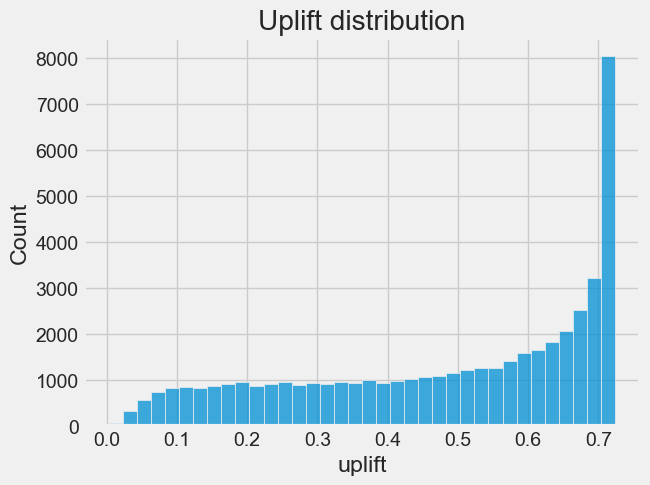


Канал: banner
Qini score: 0.20640478


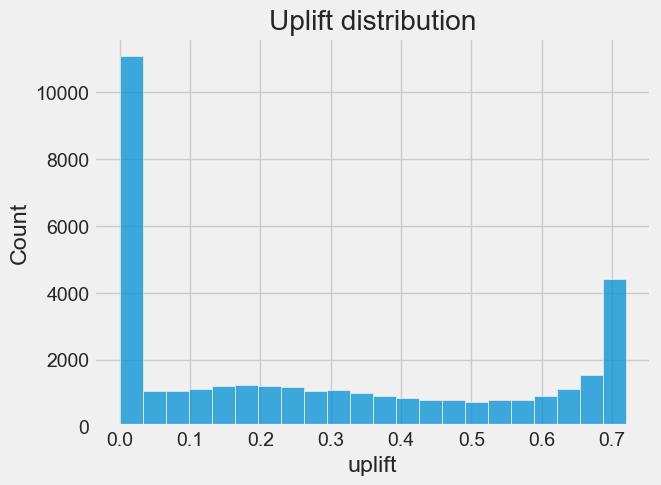


Канал: other_ads
Qini score: 0.21319670


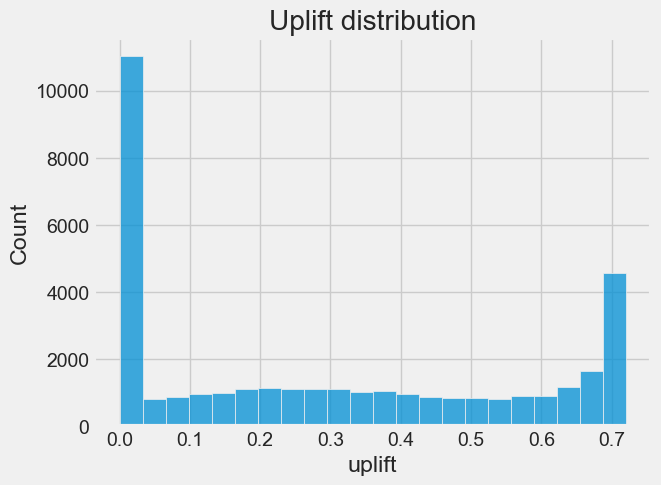

In [30]:
#СОЛО МОДЕЛЬ - БАЗОВАЯ 
for channel in channels:
    
    print(f"\nКанал: {channel}")
    
    channel_data = uplift_encoded[
        uplift_encoded['channel'] == channel
    ].copy()
    
    feature_columns = [
        col for col in channel_data.columns
        if col not in ['user_id', 'channel', 'target']
    ]
    
    X = channel_data[feature_columns]
    y = channel_data['target']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )
    
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    
    X_test_0 = X_test.copy()
    X_test_0['t_flag'] = 0
    y_pred_0 = model.predict_proba(X_test_0)[:, 1]

    X_test_1 = X_test.copy()
    X_test_1['t_flag'] = 1
    y_pred_1 = model.predict_proba(X_test_1)[:, 1]

    uplift = y_pred_1 - y_pred_0
    
    treatment_test = X_test['t_flag']
    
    qini = qini_auc_score(
        y_true=y_test,
        uplift=uplift,
        treatment=treatment_test
    )
    
    print(f"Qini score: {qini:.8f}")
    
    uplift_pd = pd.DataFrame(
        data=uplift,
        index=X_test.index,
        columns=['uplift']
    ).sort_values(by='uplift', ascending=False)
    
    sns.histplot(data=uplift_pd, x='uplift')
    plt.title('Uplift distribution')
    plt.show()

In [31]:
#ПОЛЬЗОВАЛСЯ LLM ДЛЯ ПОНИМАНИЯ В ЦЕЛОМ ПРОЦЕССА АПЛИФТА - САМО ЗНАЧЕНИЕ КОТОРОЕ ИЩЕМ И ЕГО ЛОГИКУ УЖЕ ПРИ ОБУЧЕНИИ - А ТАКЖЕ САМ ТЮНИНГ КОДА И ПОДСКАЗКИ ПО МОДЕЛЯМ ДЛЯ КАЖДОГО КАНАЛА
results = {}
models = {}
uplift_predictions = {}
uplift_stats = []

for channel in channels:
    
    channel_data = uplift_encoded[
        uplift_encoded['channel'] == channel
    ].copy()
    
    feature_columns = [
        col for col in channel_data.columns
        if col not in ['user_id', 'channel', 'target', 't_flag']
    ]
    
    X = channel_data[feature_columns]
    y = channel_data['target']
    treatment = channel_data['t_flag']
    user_ids = channel_data['user_id']
    
    stratify_cols = channel_data[['t_flag', 'target']] \
        .apply(lambda row: f"{row['t_flag']}_{row['target']}", axis=1)
    
    X_train, X_test, y_train, y_test, tr_train, tr_test, user_train, user_test = train_test_split(
        X,
        y,
        treatment,
        user_ids,
        test_size=0.3,
        random_state=42,
        stratify=stratify_cols
    )
    
    model = SoloModel(
        estimator=LogisticRegression(
            random_state=42,
            max_iter=3000,
            C=15
        )
    )
    
    model.fit(
        X_train,
        y_train,
        treatment=tr_train
    )
    
    models[channel] = model
    
    uplift_pred = model.predict(X_test)
    
    channel_results = pd.DataFrame({
        'user_id': user_test.values,
        'channel': channel,
        'uplift': uplift_pred,
        'treatment': tr_test.values,
        'target': y_test.values
    })
    
    uplift_predictions[channel] = channel_results

all_uplift = pd.concat(uplift_predictions.values(), ignore_index=True)
all_uplift_sorted = all_uplift.sort_values('uplift', ascending=False)

Канал: push
Qini score: 0.16937726


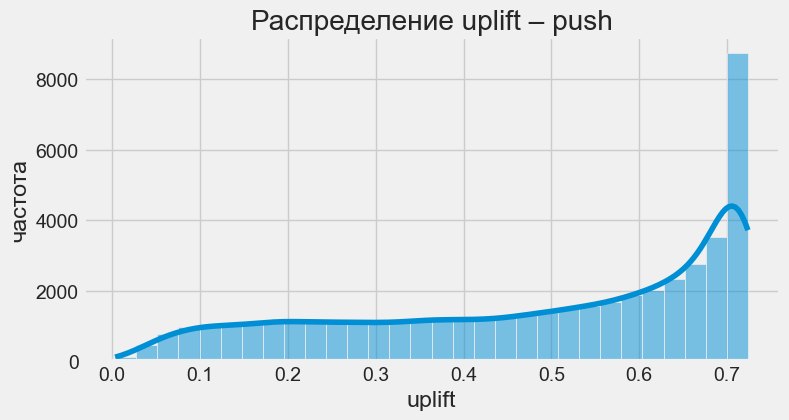

Канал: banner
Qini score: 0.20481476


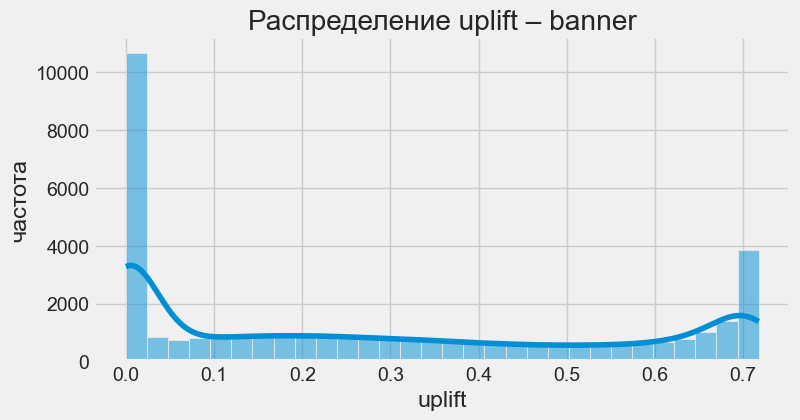

Канал: other_ads
Qini score: 0.21273738


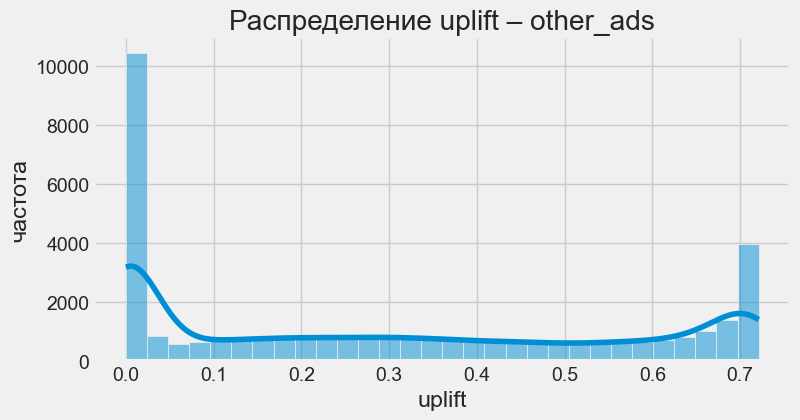

In [32]:
for channel, df in uplift_predictions.items():
    print(f"Канал: {channel}")
    
    y_true = df['target'].values
    uplift = df['uplift'].values
    treatment = df['treatment'].values
    
    qini = qini_auc_score(y_true, uplift, treatment)
    print(f"Qini score: {qini:.8f}")
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df['uplift'], bins=30, kde=True)
    plt.title(f'Распределение uplift – {channel}')
    plt.xlabel('uplift')
    plt.ylabel('частота')
    plt.show()

In [33]:
results = {}
models = {}
uplift_predictions = {}
uplift_stats = []

for channel in channels:
    
    channel_data = uplift_encoded[
        uplift_encoded['channel'] == channel
    ].copy()
    
    feature_columns = [
        col for col in channel_data.columns
        if col not in ['user_id', 'channel', 'target', 't_flag']
    ]
    
    X = channel_data[feature_columns]
    y = channel_data['target']
    treatment = channel_data['t_flag']
    user_ids = channel_data['user_id']
    
    stratify_cols = channel_data[['t_flag', 'target']] \
        .apply(lambda row: f"{row['t_flag']}_{row['target']}", axis=1)
    
    X_train, X_test, y_train, y_test, tr_train, tr_test, user_train, user_test = train_test_split(
        X,
        y,
        treatment,
        user_ids,
        test_size=0.3,
        random_state=42,
        stratify=stratify_cols
    )
    
    base_model = LogisticRegression(
        random_state=42,
        max_iter=3000,
        C=15
    )
    
    calibrated_model = CalibratedClassifierCV(
        base_model,
        method='sigmoid',  
        cv=5
    )
    
    model = ClassTransformation(estimator=calibrated_model)
    
    model.fit(
        X_train,
        y_train,
        treatment=tr_train
    )
    
    models[channel] = model
    
    uplift_pred = model.predict(X_test)
    
    channel_results = pd.DataFrame({
        'user_id': user_test.values,
        'channel': channel,
        'uplift': uplift_pred,
        'treatment': tr_test.values,
        'target': y_test.values
    })
    
    uplift_predictions[channel] = channel_results

Канал: push
Qini score: 0.30344580


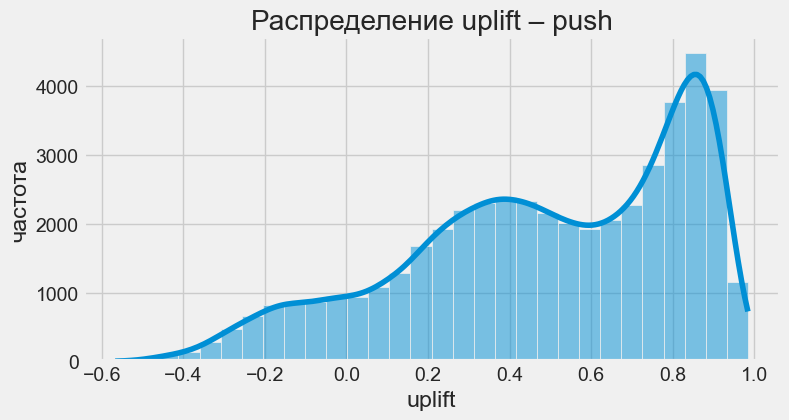

Канал: banner
Qini score: 0.20832832


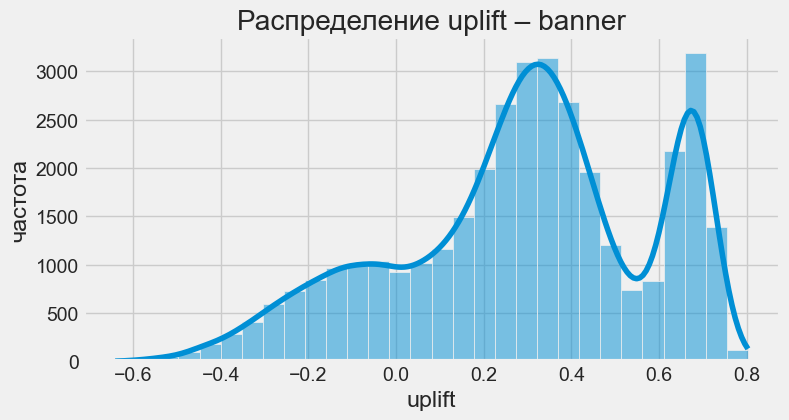

Канал: other_ads
Qini score: 0.21964296


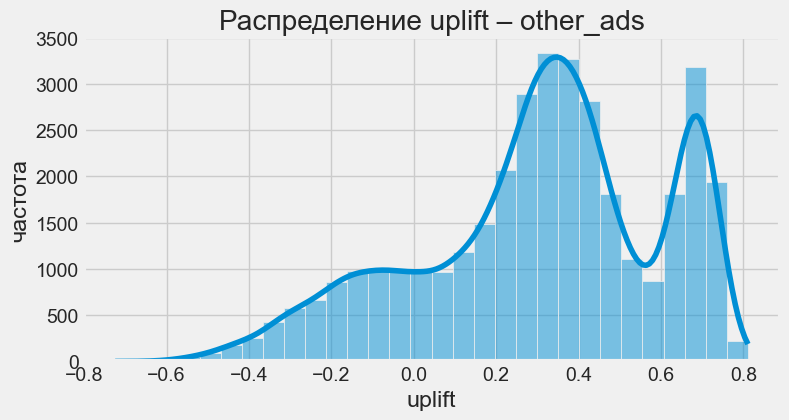

In [34]:
for channel, df in uplift_predictions.items():
    print(f"Канал: {channel}")
    
    y_true = df['target'].values
    uplift = df['uplift'].values
    treatment = df['treatment'].values
    
    qini = qini_auc_score(y_true, uplift, treatment)
    print(f"Qini score: {qini:.8f}")
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df['uplift'], bins=30, kde=True)
    plt.title(f'Распределение uplift – {channel}')
    plt.xlabel('uplift')
    plt.ylabel('частота')
    plt.show()

In [75]:
from sklearn.preprocessing import StandardScaler

results = {}
models_final = {}
scalers = {}  # словарь для сохранения scaler'ов по каналам
uplift_predictions_classTrans = {}
uplift_stats = []

for channel in channels:
    
    channel_data = uplift_encoded[
        uplift_encoded['channel'] == channel
    ].copy()
    
    feature_columns = [
        col for col in channel_data.columns
        if col not in ['user_id', 'channel', 'target', 't_flag']
    ]
    
    X = channel_data[feature_columns]
    y = channel_data['target']
    treatment = channel_data['t_flag']
    user_ids = channel_data['user_id']
    
    stratify_cols = channel_data[['t_flag', 'target']] \
        .apply(lambda row: f"{row['t_flag']}_{row['target']}", axis=1)
    
    X_train, X_test, y_train, y_test, tr_train, tr_test, user_train, user_test = train_test_split(
        X,
        y,
        treatment,
        user_ids,
        test_size=0.3,
        random_state=42,
        stratify=stratify_cols
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    scalers[channel] = scaler
    
    base_model = LogisticRegression(
        random_state=42,
        max_iter=3000,
        C=15
    )
    
    calibrated_model = CalibratedClassifierCV(
        base_model,
        method='sigmoid',  
        cv=5
    )
    
    model = ClassTransformation(estimator=calibrated_model)
    
    model.fit(
        X_train_scaled,   
        y_train,
        treatment=tr_train
    )
    
    models_final[channel] = model
    
    uplift_pred = model.predict(X_test_scaled)
    
    channel_results = pd.DataFrame({
        'user_id': user_test.values,
        'channel': channel,
        'uplift': uplift_pred,
        'treatment': tr_test.values,
        'target': y_test.values
    })
    
    uplift_predictions_classTrans[channel] = channel_results

Канал: push
Qini score: 0.30345279


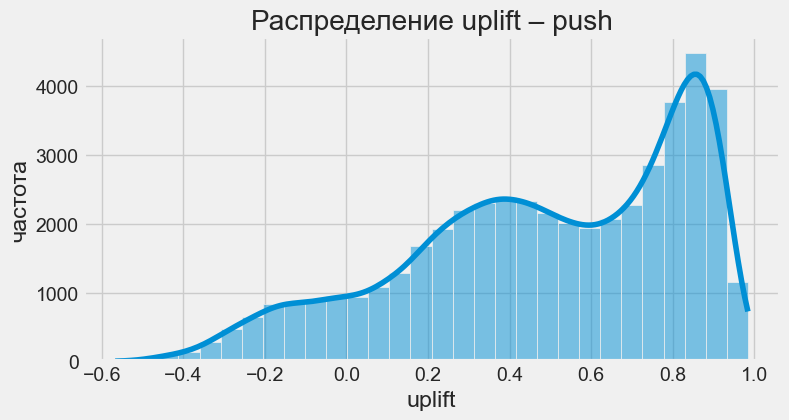

Канал: banner
Qini score: 0.20831980


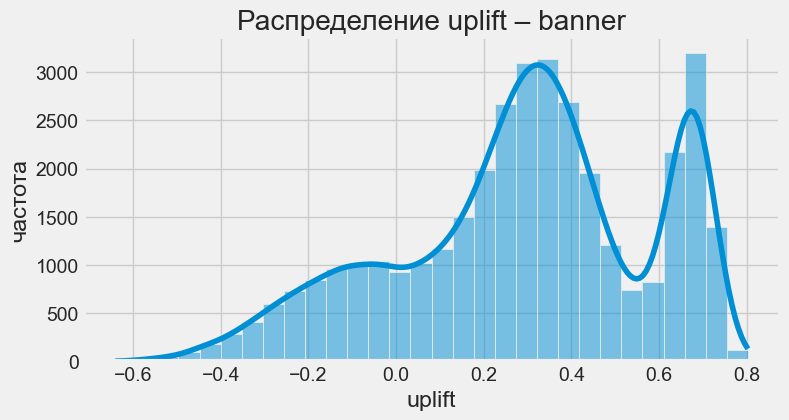

Канал: other_ads
Qini score: 0.21972537


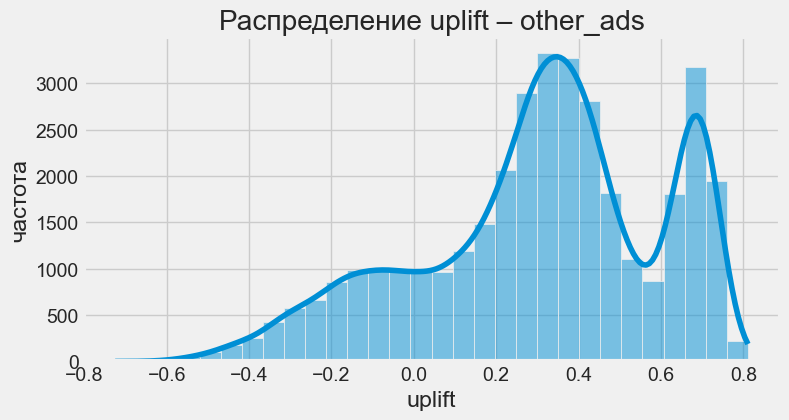

In [76]:
for channel, df in uplift_predictions_classTrans.items():
    print(f"Канал: {channel}")
    
    y_true = df['target'].values
    uplift = df['uplift'].values
    treatment = df['treatment'].values
    
    qini = qini_auc_score(y_true, uplift, treatment)
    print(f"Qini score: {qini:.8f}")
    
    plt.figure(figsize=(8, 4))
    sns.histplot(df['uplift'], bins=30, kde=True)
    plt.title(f'Распределение uplift – {channel}')
    plt.xlabel('uplift')
    plt.ylabel('частота')
    plt.show()

Qini score: 0.31804183


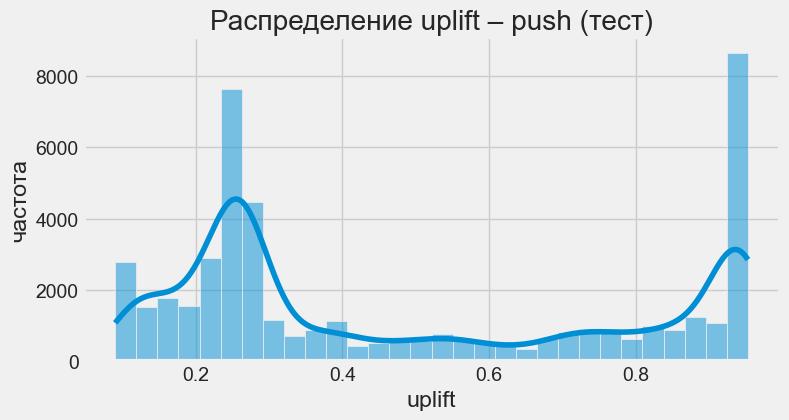

Qini score: 0.19477957


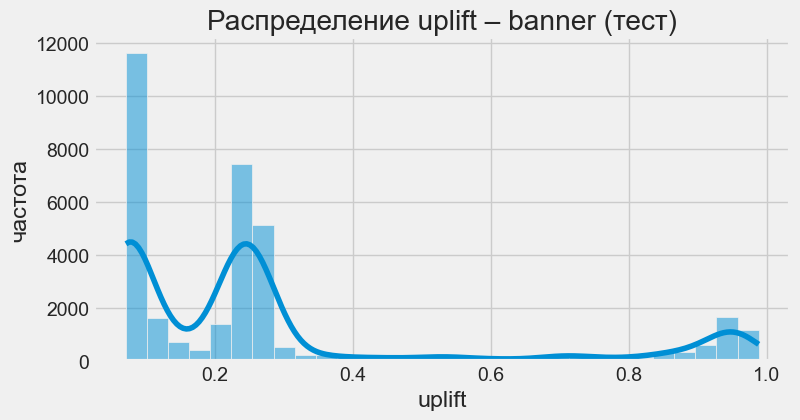

Qini score: 0.20476397


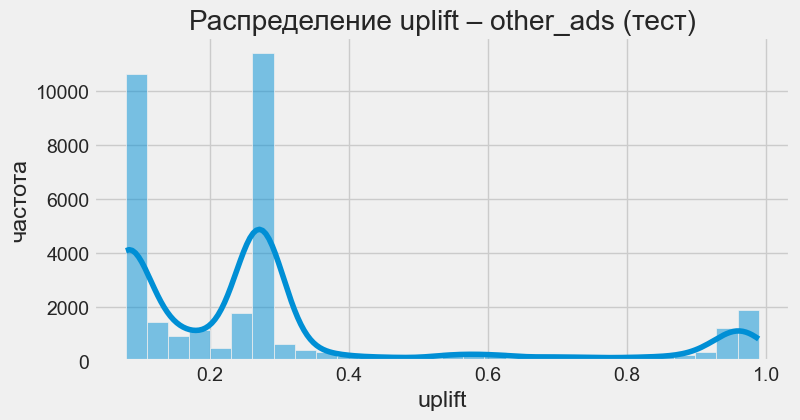

In [82]:
results = {}
models = {}
uplift_predictions = {}
uplift_stats = []

for channel in channels:
    channel_data = uplift_encoded[
        uplift_encoded['channel'] == channel
    ].copy()
    
    feature_columns = [
        col for col in channel_data.columns
        if col not in ['user_id', 'channel', 'target', 't_flag']
    ]
    
    X = channel_data[feature_columns]
    y = channel_data['target']
    treatment = channel_data['t_flag']
    user_ids = channel_data['user_id']
    
    stratify_cols = channel_data[['t_flag', 'target']].astype(str).agg('_'.join, axis=1)
    
    X_train, X_test, y_train, y_test, tr_train, tr_test, user_train, user_test = train_test_split(
        X,
        y,
        treatment,
        user_ids,
        test_size=0.3,
        random_state=42,
        stratify=stratify_cols
    )
    
    X_train_np = X_train.values
    X_test_np = X_test.values
    tr_train_np = tr_train.astype(str).values
    y_train_np = y_train.values
    
    uplift_forest = UpliftRandomForestClassifier(
        control_name='0',      
        random_state=42,
        n_estimators=100,      
        max_depth=5,           
        min_samples_leaf=50
    )
    
    uplift_forest.fit(X_train_np, tr_train_np, y_train_np)
    
    models[channel] = uplift_forest
    
    uplift_pred = uplift_forest.predict(X_test_np)

    channel_results = pd.DataFrame({
        'user_id': user_test.values,
        'channel': channel,
        'uplift': uplift_pred.flatten(),
        'treatment': tr_test.values,
        'target': y_test.values
    })
    
    uplift_predictions[channel] = channel_results
    
    qini = qini_auc_score(
        channel_results['target'].values,
        channel_results['uplift'].values,
        channel_results['treatment'].values
    )
    print(f"Qini score: {qini:.8f}")
    
    plt.figure(figsize=(8, 4))
    sns.histplot(channel_results['uplift'], bins=30, kde=True)
    plt.title(f'Распределение uplift – {channel} (тест)')
    plt.xlabel('uplift')
    plt.ylabel('частота')
    plt.show()

In [72]:
aggs['report_dt'] = pd.to_datetime(aggs['report_dt'])
aggs['year'] = aggs['report_dt'].dt.year
aggs['month'] = aggs['report_dt'].dt.month

aggs_sep = aggs[(aggs['year'] == 2025) & (aggs['month'] == 1)].copy()

aggs_sep = aggs_sep.drop_duplicates(subset=['user_id'])

uplift_aggs = uplift_full.merge(
    aggs_sep[['user_id', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'age', 'city']],
    left_on='client_id',
    right_on='user_id',
    how='left'
)

required_columns = ['user_id', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 
                    'age', 'city', 't_flag', 'target']

uplift_final_march = uplift_aggs[required_columns]

print(len(uplift_final_march))
print(uplift_final_march.head(15))

400000
    user_id        x1        x2        x3        x4        x5        x6  \
0      1162 -1.440386  2.626965 -0.554468  1.256096 -0.126117  0.796936   
1     42991 -2.876481  0.825156  0.096972  1.522668 -0.480667  0.516981   
2     24623 -0.926523  1.672010 -2.129563  0.495003 -0.128326 -1.384427   
3    116064 -2.293670  1.704625  1.542012  3.046442 -0.546986  0.081610   
4    139714 -0.809680 -1.098839 -1.083334  0.748490 -1.987580  0.826941   
5    127278 -1.053819  0.190672 -1.281406  0.516182 -1.314703 -0.499449   
6    113131 -4.225216  1.983249  1.730457  4.246921  1.789712  1.421132   
7       709  0.245321 -0.448345 -2.219483  2.348014  1.679128 -0.180929   
8     66294  3.127204  0.408344 -2.047632  0.244942 -2.739726 -2.178474   
9      3365 -0.795623  0.246468 -1.581419  1.382818  3.067439 -0.998729   
10    35254  1.711726 -0.420915 -2.128726  0.350654  1.677111 -0.226212   
11    17423  3.112730 -2.922272  0.529293 -0.601987 -1.089111 -0.000643   
12   137984  0.023

    user_id  uplift_push  uplift_banner  uplift_other_ads best_channel  \
0      1162     0.274114       0.110478          0.138464         push   
1     42991     0.201572       0.931695          0.946857    other_ads   
2     24623     0.580815       0.090937          0.094066         push   
3    116064     0.112502       0.484476          0.486748    other_ads   
4    139714     0.239565       0.268009          0.262890       banner   
5    127278     0.496212       0.292030          0.328075         push   
6    113131     0.463907       0.560862          0.416242       banner   
7       709     0.478110       0.268009          0.262890         push   
8     66294     0.600878       0.268009          0.262890         push   
9      3365     0.478110       0.090937          0.090445         push   
10    35254     0.876434       0.087776          0.088712         push   
11    17423     0.736251       0.295947          0.268449         push   
12   137984     0.309935       0.08777

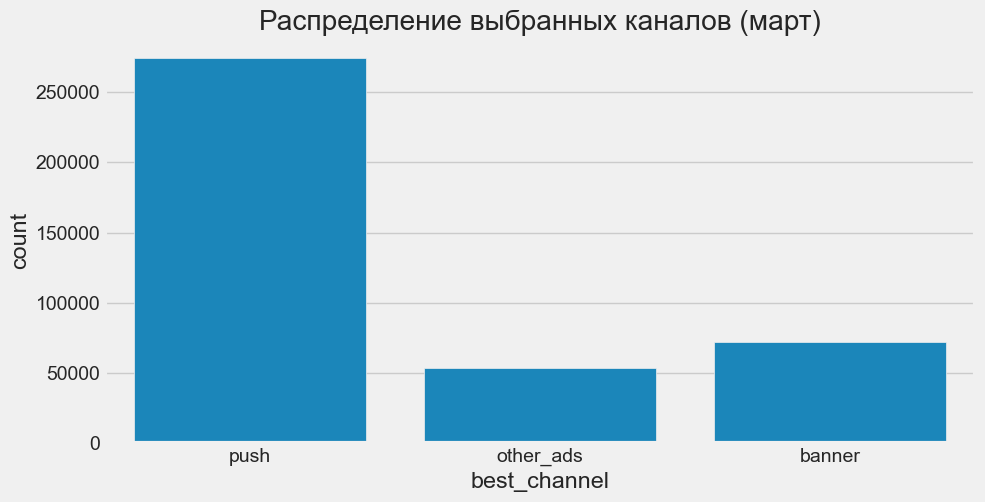

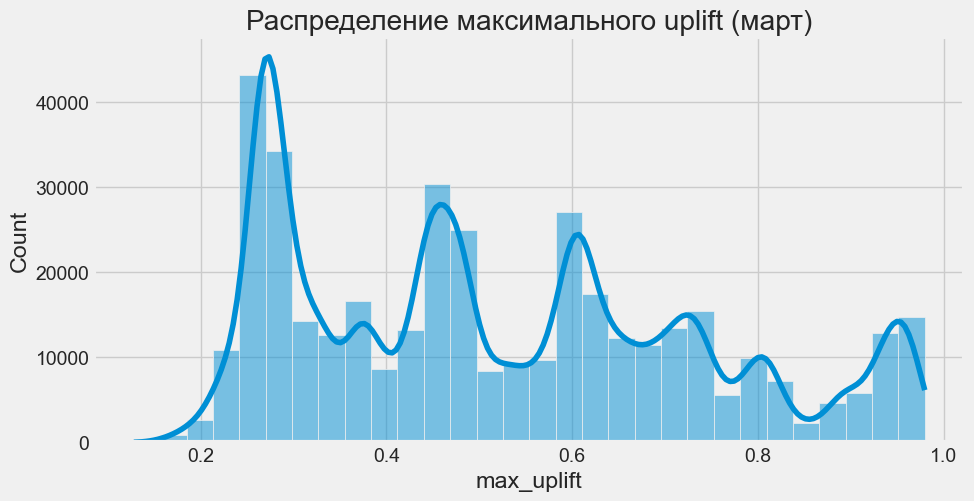

In [83]:
march_data = uplift_final_march.copy()

numeric_cols = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'age']
for col in numeric_cols:
    median_val = uplift_encoded[col].median()
    march_data[col].fillna(median_val, inplace=True)

city_march_encoded = encoder.transform(march_data[['city']])
city_march_df = pd.DataFrame(
    city_march_encoded,
    columns=encoder.get_feature_names_out(['city']),
    index=march_data.index
)

march_encoded = pd.concat(
    [march_data.drop('city', axis=1), city_march_df],
    axis=1
)
train_feature_columns = [col for col in uplift_encoded.columns 
                         if col not in ['user_id', 'channel', 'target', 't_flag']]

missing = set(train_feature_columns) - set(march_encoded.columns)
if missing:
    print(f"Добавляю недостающие колонки (заполняю нулями): {missing}")
    for col in missing:
        march_encoded[col] = 0

march_encoded = march_encoded[train_feature_columns]

X_all = march_encoded.values
user_ids = march_data['user_id'].values 

uplift_per_channel = {}
for channel, model in models.items():
    scaler = scalers[channel]
    X_scaled = scaler.transform(X_all)
    uplift_pred = model.predict(X_scaled)
    uplift_per_channel[channel] = uplift_pred.flatten()

results_df = pd.DataFrame({
    'user_id': user_ids,
    **{f'uplift_{ch}': uplift_per_channel[ch] for ch in models_final.keys()}
})

uplift_cols = [f'uplift_{ch}' for ch in models_final.keys()]
results_df['best_channel'] = results_df[uplift_cols].idxmax(axis=1).str.replace('uplift_', '')
results_df['max_uplift'] = results_df[uplift_cols].max(axis=1)

print(results_df.head(15))

plt.figure(figsize=(10,5))
sns.countplot(data=results_df, x='best_channel')
plt.title('Распределение выбранных каналов (март)')
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(results_df['max_uplift'], bins=30, kde=True)
plt.title('Распределение максимального uplift (март)')
plt.show()

<h2>4. Подготовка ответа в требуемом формате и подготовка выводов (6 баллов)</h2>

a) Сделайте скоринг нужных клиентов, подготовьте ответ в требуемом формате

б) Сделайте краткую аналитику того, какой канал взаимодействия наиболее предпочтителен

в) Сделайте выводы по проделанной работе

**Комментарий по заданиям и оцениванию:**

* Подготовлен только ответ - **1 балл**
* Подготовлен содержательный вывод по проделанной работе - **4 балла**
* Корректно принято решение об отправке/не отправке коммуникации клиентам в зависимости от значений Uplift - **1 балл**

In [90]:
# ваш код здесь
threshold = results_df['max_uplift'].quantile(0.3)
print(f"Порог отсечения (30-й перцентиль): {threshold}")

results_df['channel'] = results_df.apply(
    lambda row: row['best_channel'] if row['max_uplift'] > threshold else 'no_comm',
    axis=1
)

final_pred = results_df[['user_id', 'channel', 'max_uplift']].copy()
final_pred.rename(columns={'max_uplift': 'uplift'}, inplace=True)

final_pred.loc[final_pred['channel'] == 'no_comm', 'uplift'] = 0

final_pred['report_dt'] = pd.to_datetime('2025-01-31')

print(final_pred.head(50))

Порог отсечения (30-й перцентиль): 0.36029925281531117
    user_id    channel    uplift  report_dt
0      1162    no_comm  0.000000 2025-01-31
1     42991  other_ads  0.946857 2025-01-31
2     24623       push  0.580815 2025-01-31
3    116064  other_ads  0.486748 2025-01-31
4    139714    no_comm  0.000000 2025-01-31
5    127278       push  0.496212 2025-01-31
6    113131     banner  0.560862 2025-01-31
7       709       push  0.478110 2025-01-31
8     66294       push  0.600878 2025-01-31
9      3365       push  0.478110 2025-01-31
10    35254       push  0.876434 2025-01-31
11    17423       push  0.736251 2025-01-31
12   137984    no_comm  0.000000 2025-01-31
13    58389       push  0.478110 2025-01-31
14   141699    no_comm  0.000000 2025-01-31
15   132908       push  0.446140 2025-01-31
16   124297    no_comm  0.000000 2025-01-31
17   102276       push  0.528078 2025-01-31
18   127123       push  0.450486 2025-01-31
19    58929    no_comm  0.000000 2025-01-31
20    69294  other_ad

Провел uplift-моделирование - но если рефлексировать - хочется получить отзыв от ментора по этой работе. Так как если правдиво оценивать - данные получились нереальные.

Если оценивать работу объективно, результаты получились не вполне реалистичными. На мой взгляд, наибольшее доверие вызывает модель с калибровкой — там uplift предсказывался в пределах [-0.6, 0.7], что выглядит правдоподобно.

Остался вопрос к модели UpliftRandomForestClassifier: не совсем понятно, почему она не спрогнозировала отрицательные значения uplift'а. Однако интересно, что при этом метрика Qini Score оказалась вполне достойной — в районе 0.2–0.3, что для uplift-моделирования считается хорошим показателем качества.

Возможно, это была пуш/баннер/другая реклама, которая хотела рассказать о 90 процентной скидке))

В итоге для практического применения я решил отсечь 30% пользователей с самым низким uplift'ом (нижняя квантиль 0.3). Исходил из логики: если эффект действительно такой высокий, как показывает модель, то бизнесу не стоит тратить бюджет на коммуникацию с наименее перспективной аудиторией.

Еще как вариант я рассматривал и смотрел распределения - возможно в новом году кампания сделал акцент на пользователей убеждаемых и лояльных к нам ( в условиях нынешней экономической ситуации я это тоже не исключаю)

В целом, хотел бы отметить крутость этой задачи - спасибо за такую бизнес таску - с нетерпением жду отзыв!


Результат можно вывести целиком - я вывел первые 50 строк для понимания и визуальности.